In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv('noshowappointments-may-2016.csv')
df.head(10)

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No
5,9.598513e+13,5626772,F,2016-04-27T08:36:51Z,2016-04-29T00:00:00Z,76,REPÚBLICA,0,1,0,0,0,0,No
6,7.336882e+14,5630279,F,2016-04-27T15:05:12Z,2016-04-29T00:00:00Z,23,GOIABEIRAS,0,0,0,0,0,0,Yes
7,3.449833e+12,5630575,F,2016-04-27T15:39:58Z,2016-04-29T00:00:00Z,39,GOIABEIRAS,0,0,0,0,0,0,Yes
8,5.639473e+13,5638447,F,2016-04-29T08:02:16Z,2016-04-29T00:00:00Z,21,ANDORINHAS,0,0,0,0,0,0,No
9,7.812456e+13,5629123,F,2016-04-27T12:48:25Z,2016-04-29T00:00:00Z,19,CONQUISTA,0,0,0,0,0,0,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [5]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [6]:
sum(df.duplicated(subset=['PatientId']))

48228

In [7]:
sum(df.duplicated(subset=['AppointmentID']))

0

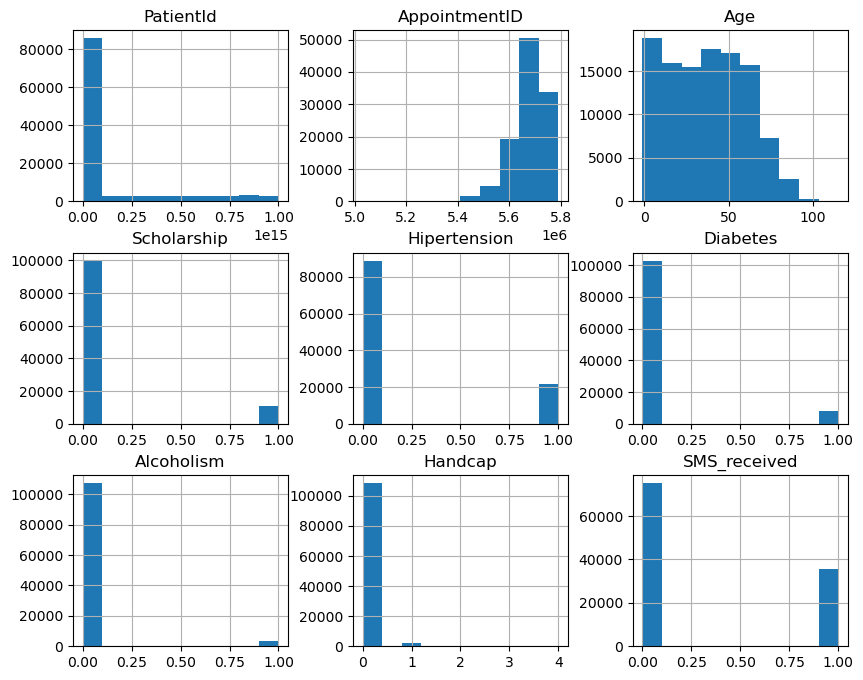

In [8]:
df.hist(figsize=(10,8));

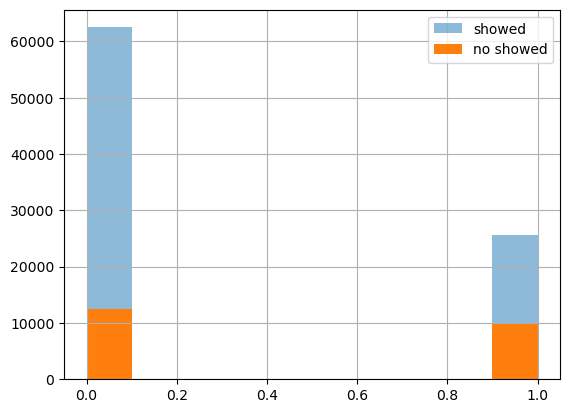

In [10]:
showed = df['No-show'] == 'No'
no_showed = df['No-show'] == 'Yes'

df.SMS_received[showed].hist(alpha=0.5, label='showed')
df.SMS_received[no_showed].hist(label='no showed')
plt.legend();

In [16]:
SMS_showed = df.SMS_received[showed].count() / df['No-show'].count()
SMS_showed

np.float64(0.798067440534892)

In [17]:
SMS_no_showed = df.SMS_received[no_showed].count() / df['No-show'].count()
SMS_no_showed

np.float64(0.20193255946510807)

In [27]:
# This renames 'No-show' or 'No-Show' to 'NoShow' automatically
df.columns = df.columns.str.replace('-', '').str.strip()
df = df.rename(columns={
    'Noshow': 'NoShow',   # handles 'No-show'
    'No_show': 'NoShow',  # handles 'No_show'
    'Noshow ': 'NoShow',  # handles trailing space edge case
})
df['NoShow'] = (df['NoShow'] == 'Yes').astype(int)
# Verify column names just in case by printing them
print("Verified columns in dataset:", df.columns.tolist())

Verified columns in dataset: ['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'NoShow', 'LeadTime', 'LeadTimeCohort']


In [28]:
# 2. Convert to datetime and calculate LeadTime
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])
df['LeadTime'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

# Remove negative lead time data entry errors
df = df[df['LeadTime'] >= 0]

# 3. Bin Lead Times into Strategic Operational Cohorts
bins = [0, 1, 3, 7, 14, 30, 180]
labels = ['Same-Day', '1-3 Days', '4-7 Days', '8-14 Days', '15-30 Days', '30+ Days']
df['LeadTimeCohort'] = pd.cut(df['LeadTime'], bins=bins, labels=labels, include_lowest=True)

# 4. Calculate Aggregated No-Show Probabilities (Using the verified 'NoShow' name)
cohort_analysis = df.groupby('LeadTimeCohort', observed=False).agg(
    total_appointments=('NoShow', 'count'),
    no_show_count=('NoShow', 'sum'),
    no_show_rate=('NoShow', 'mean')
).reset_index()

# View the clean dataframe
print(cohort_analysis)


  LeadTimeCohort  total_appointments  no_show_count  no_show_rate
0       Same-Day               43776           2905      0.066361
1       1-3 Days                9462           2246      0.237371
2       4-7 Days               17510           4413      0.252027
3      8-14 Days               12025           3664      0.304699
4     15-30 Days               17371           5661      0.325888
5       30+ Days               10378           3425      0.330025


In [29]:
sms_cohort = df.groupby(['LeadTimeCohort', 'SMS_received'], observed=False).agg(
    total=('NoShow', 'count'),
    no_shows=('NoShow', 'sum'),
    no_show_rate=('NoShow', 'mean')
).reset_index()

sms_cohort['SMS_received'] = sms_cohort['SMS_received'].map({0: 'No SMS', 1: 'SMS Sent'})
print(sms_cohort)

   LeadTimeCohort SMS_received  total  no_shows  no_show_rate
0        Same-Day       No SMS  43776      2905      0.066361
1        Same-Day     SMS Sent      0         0           NaN
2        1-3 Days       No SMS   8556      2053      0.239949
3        1-3 Days     SMS Sent    906       193      0.213024
4        4-7 Days       No SMS   6868      1862      0.271112
5        4-7 Days     SMS Sent  10642      2551      0.239711
6       8-14 Days       No SMS   5021      1695      0.337582
7       8-14 Days     SMS Sent   7004      1969      0.281125
8      15-30 Days       No SMS   6851      2526      0.368705
9      15-30 Days     SMS Sent  10520      3135      0.298004
10       30+ Days       No SMS   3968      1489      0.375252
11       30+ Days     SMS Sent   6410      1936      0.302028


In [30]:
pivot = sms_cohort.pivot(index='LeadTimeCohort', columns='SMS_received', values='no_show_rate')
pivot['sms_lift'] = pivot['No SMS'] - pivot['SMS Sent']  # positive = SMS helped
pivot['sms_lift_pct'] = (pivot['sms_lift'] / pivot['No SMS']) * 100  # relative reduction
print(pivot.round(3))

SMS_received    No SMS  SMS Sent  sms_lift  sms_lift_pct
LeadTimeCohort                                          
Same-Day         0.066       NaN       NaN           NaN
1-3 Days         0.240     0.213     0.027        11.221
4-7 Days         0.271     0.240     0.031        11.583
8-14 Days        0.338     0.281     0.056        16.724
15-30 Days       0.369     0.298     0.071        19.176
30+ Days         0.375     0.302     0.073        19.513


In [31]:
sms_cohort.to_csv('sms_cohort_analysis.csv', index=False)

In [32]:
cohort_analysis.to_csv('cohort_analysis.csv', index=False)

In [36]:
df.to_csv('noshowappointments_may_2016_cleaned.csv', index=False)